<a href="https://colab.research.google.com/github/rachelhostetler/ABCAtlas_UseCases/blob/main/Plotting_10x_sc_gene_expression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Allen Brain Cell Atlas Use Case
This notebook is an example of how to use data from the Allen Brain Cell (ABC) Atas. Code for this notebook comes from [ABC Atlas Access](https://alleninstitute.github.io/abc_atlas_access/intro.html), which features in depth tutorials on ABC Atlas scRNAseq and MERFISH datasets. Use ABC Atlas Access to learn more about each of the datasets. The text following '#' are comments and/or indicate where the code can be edited to look at different brain regions, cell types, etc. This notebook is intended to be used in Google Colab.
## Use Case Description
A scientist studies glutamatergic transmission in the midbrain. The are studying the glutamate transporters VGluT1, VGluT2, and VGluT3. They want to plot the expression of these three transporters within specific classes, subclasses, supertypes, and/or clusters within the midbrain.  [Here](https://knowledge.brain-map.org/abcatlas#AQEBQVA4Sk5ONUxZQUJHVk1HS1kxQgACUTFOQ1dXUEc2RlowRE5JWEpCUQADAgFOM1lFRzg0NUpTSVBNUzNDME1KAAIBMTBYdjMAAAFZOTM3Q1ZVU1ZaQzdLWU9IV1ZPAAIBTUIAAAQBAQKBcKJYgSKeBwOF5LUDhKI6ewAFAwFTbGMxN2E2AAABU2xjMTdhNwAAAVNsYzE3YTgAAAYBAAJTbGMxN2E2AAN%2BAAAABAAFgC7zYoKmtnQGkHYHAiNGRkZGRkYAAwAGR0VORQAHAAgBCQAAAAhHNEk0R0ZKWEpCOUFUWjNQVFgxAAlMVkRCSkFXOEJJNVlTUzFRVUJHAAoACwFub25lAAJub25lAAMBBAEAAiMwMDAwMDAAA8gBAAUBAQIjMDAwMDAwAAPIAQAAAAIBAwAA) are the cells and genes they are studying in the ABC Atlas.

Goal: plot gene expression of glutamate transporters VGluT1 (Slc17a7), VGluT2 (Slc17a6), and VGluT3 (Slc17a8) in the midbrain.

In [ ]:
# Install s3fs package
!apt install s3fs

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
s3fs is already the newest version (1.90-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
# Make directory to mount s3 data into
!mkdir -p /data/abc_atlas

In [ ]:
# Mount the s3 bucket using s3fs-fuse
!s3fs -o public_bucket=1 -o default_acl=public-read -o endpoint="us-west-2" allen-brain-cell-atlas /data/abc_atlas

s3fs: MOUNTPOINT directory /data/abc_atlas is not empty. if you are sure this is safe, can use the 'nonempty' mount option.


In [ ]:
# Check that it's mounted
!ls -ltrh /data/abc_atlas

total 35K
drwxr-x--- 1 root root   0 Dec 31  1969 releases
drwxr-x--- 1 root root   0 Dec 31  1969 metadata
drwxr-x--- 1 root root   0 Dec 31  1969 mapmycells
drwxr-x--- 1 root root   0 Dec 31  1969 image_volumes
drwxr-x--- 1 root root   0 Dec 31  1969 expression_matrices
-rw-r----- 1 root root 32K Jun  7  2023 index.html


In [ ]:
# Install abc_atlas_access
%pip install "abc_atlas_access[notebooks] @ git+https://github.com/alleninstitute/abc_atlas_access.git"

  Cloning https://github.com/alleninstitute/abc_atlas_access.git to /tmp/pip-install-lgptjp5u/abc-atlas-access_d40e023e29204eb9a85c4c2d26052202
  Running command git clone --filter=blob:none --quiet https://github.com/alleninstitute/abc_atlas_access.git /tmp/pip-install-lgptjp5u/abc-atlas-access_d40e023e29204eb9a85c4c2d26052202
  Resolved https://github.com/alleninstitute/abc_atlas_access.git to commit 697e2096268f3a1d89394be589323e5ae0a1bbdd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from pathlib import Path
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [ ]:
download_base = Path('/data/abc_atlas')
abc_cache = AbcProjectCache.from_local_cache(download_base)

abc_cache.current_manifest

/usr/local/lib/python3.12/dist-packages/abc_atlas_access/abc_atlas_cache/cloud_cache.py:519: MissingLocalManifestWarning: This cache directory appears to contain data files, but it has no record of what those files are. Unless running as a LocalCache, files will be re-downloaded.
  warnings.warn(msg, MissingLocalManifestWarning)
/usr/local/lib/python3.12/dist-packages/abc_atlas_access/abc_atlas_cache/cloud_cache.py:1490: ReadOnlyLocalCacheWarning: LocalCache is a read only directory and cannot
                save the last used manifest.
                Current Manifest: releases/20260415/manifest.json
  warnings.warn(


'releases/20260415/manifest.json'

In [ ]:
abc_cache.list_directories

['ASAP-PMDBS-10X',
 'ASAP-PMDBS-taxonomy',
 'Allen-CCF-2020',
 'Consensus-WMB-AIBS-10X',
 'Consensus-WMB-Macosko-10X',
 'Consensus-WMB-integrated-taxonomy',
 'Developing-Mouse-Vis-Cortex-10X',
 'Developing-Mouse-Vis-Cortex-taxonomy',
 'HMBA-10xMultiome-BG',
 'HMBA-10xMultiome-BG-Aligned',
 'HMBA-BG-taxonomy-CCN20250428',
 'HMBA-MERSCOPE-H22.30.001-BG',
 'HMBA-MERSCOPE-QM23.50.001-BG',
 'HMBA-Macaque-PatchSeq',
 'HMBA-Xenium-CJ23.56.004-BG',
 'MERFISH-C57BL6J-638850',
 'MERFISH-C57BL6J-638850-CCF',
 'MERFISH-C57BL6J-638850-imputed',
 'MERFISH-C57BL6J-638850-sections',
 'SEAAD-taxonomy',
 'WHB-10Xv3',
 'WHB-taxonomy',
 'WMB-10X',
 'WMB-10XMulti',
 'WMB-10Xv2',
 'WMB-10Xv3',
 'WMB-neighborhoods',
 'WMB-taxonomy',
 'Zeng-Aging-Mouse-10Xv3',
 'Zeng-Aging-Mouse-WMB-taxonomy',
 'Zhuang-ABCA-1',
 'Zhuang-ABCA-1-CCF',
 'Zhuang-ABCA-2',
 'Zhuang-ABCA-2-CCF',
 'Zhuang-ABCA-3',
 'Zhuang-ABCA-3-CCF',
 'Zhuang-ABCA-4',
 'Zhuang-ABCA-4-CCF',
 'mmc-gene-mapper']

In [ ]:
import pandas as pd
import numpy as np
import anndata
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
from abc_atlas_access.abc_atlas_cache.anndata_utils import get_gene_data

In [ ]:
# Edit the notebook from here onward
cell = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='cell_metadata_with_cluster_annotation').set_index('cell_label') # To change dataset, enter the directory name from the list above (abc_cache.list_directories).
cell.head(5) # show me first 5 cells

/usr/local/lib/python3.12/dist-packages/abc_atlas_access/abc_atlas_cache/abc_project_cache.py:643: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, **kwargs)


,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,subclass,supertype,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color
cell_label,,,,,,,,,,,,,,,,,,,,,
GCGAGAAGTTAAGGGC-410_B05,GCGAGAAGTTAAGGGC,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AATGGCTCAGCTCCTT-411_B06,AATGGCTCAGCTCCTT,411_B06,L8TX_201029_01_E10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550851,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AACACACGTTGCTTGA-410_B05,AACACACGTTGCTTGA,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
CACAGATAGAGGCGGA-410_A05,CACAGATAGAGGCGGA,410_A05,L8TX_201029_01_A10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AAAGTGAAGCATTTCG-410_B05,AAAGTGAAGCATTTCG,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C


In [ ]:
# show me the number of cells in each cell-by-gene matrix
# Whole mouse brain (WMB) cell-by-gene data is split by experimental platform (10xMutltiome, 10xv2, 10xv3) and anatomical dissections
matrices = cell.groupby(['dataset_label', 'feature_matrix_label'])[['library_label']].count()
matrices.columns  = ['cell_count']
matrices # show me all matrices

cell_count
dataset_label feature_matrix_label             
WMB-10XMulti  WMB-10XMulti                 1687
WMB-10Xv2     WMB-10Xv2-CTXsp             43985
              WMB-10Xv2-HPF              207281
              WMB-10Xv2-HY                99879
              WMB-10Xv2-Isocortex-1      248776
              WMB-10Xv2-Isocortex-2      249360
              WMB-10Xv2-Isocortex-3      249356
              WMB-10Xv2-Isocortex-4      248784
              WMB-10Xv2-MB                29781
              WMB-10Xv2-OLF              192182
              WMB-10Xv2-TH               130555
WMB-10Xv3     WMB-10Xv3-CB               181723
              WMB-10Xv3-CTXsp             78223
              WMB-10Xv3-HPF              181055
              WMB-10Xv3-HY               162296
              WMB-10Xv3-Isocortex-1      227670
              WMB-10Xv3-Isocortex-2      227537
              WMB-10Xv3-MB               337101
              WMB-10Xv3-MY               191746
              WMB-10Xv3-OLF               88560
              WMB-10Xv3-P                143157
              WMB-10Xv3-PAL              108046
              WMB-10Xv3-STR              283782
              WMB-10Xv3-TH               130454

In [ ]:
# get genes from dataset and show me the first 5
gene = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='gene').set_index('gene_identifier') # To change dataset, enter the directory name from the list above (abc_cache.list_directories).
gene.head(5) # show me first 5 genes



,gene_symbol,name,mapped_ncbi_identifier,comment
gene_identifier,,,,
ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,NCBIGene:497097,NaN
ENSMUSG00000089699,Gm1992,predicted gene 1992,NaN,NaN
ENSMUSG00000102331,Gm19938,"predicted gene, 19938",NaN,NaN
ENSMUSG00000102343,Gm37381,"predicted gene, 37381",NaN,NaN
ENSMUSG00000025900,Rp1,retinitis pigmentosa 1 (human),NCBIGene:19888,NaN


In [ ]:
# check if gene of interest is present in dataset
if (len(gene[gene['gene_symbol'] == 'Slc17a8'])>0): # edit which gene you are looking for here
    print('This gene is present')
else:
    print('This gene is not present')

This gene is present


In [ ]:
# choose which cell-by-gene matrix you want to use and show me first 5 cells
matrix_cells = cell[cell['feature_matrix_label'] == 'WMB-10Xv3-MB'] # edit cell-by-gene matrix here
matrix_cells.head(5) # show me first 5 cells


,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,subclass,supertype,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color
cell_label,,,,,,,,,,,,,,,,,,,,,
TCATTCATCGAATGCT-211_B01,TCATTCATCGAATGCT,211_B01,L8TX_200130_01_D01,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-506920,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,041 OB-in Frmd7 Gaba,0154 OB-in Frmd7 Gaba_5,0561 OB-in Frmd7 Gaba_5,#FF3358,#1b4332,#FF0073,#BD1FCC,#0BCC00,25,#CC5CB0
CTCAGAAGTAGCCAGA-420_D06,CTCAGAAGTAGCCAGA,420_D06,L8TX_201106_01_H03,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-551017,Ai14(RCL-tdT)/wt,...,045 OB-STR-CTX Inh IMN,0166 OB-STR-CTX Inh IMN_1,0598 OB-STR-CTX Inh IMN_1,#666666,#1b4332,#819945,#2d42b7,#CC987A,25,#CC5CB0
CCTCACATCAGGCGAA-425_D03,CCTCACATCAGGCGAA,425_D03,L8TX_201113_01_G07,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-551640,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,038 DG-PIR Ex IMN,0141 DG-PIR Ex IMN_2,0513 DG-PIR Ex IMN_2,#2B93DF,#16f2f2,#3D53CC,#CC7A3D,#69CC1F,25,#CC5CB0
CTCCTCCCACGTCGTG-425_C03,CTCCTCCCACGTCGTG,425_C03,L8TX_201112_01_F05,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-551640,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,038 DG-PIR Ex IMN,0141 DG-PIR Ex IMN_2,0513 DG-PIR Ex IMN_2,#2B93DF,#16f2f2,#3D53CC,#CC7A3D,#69CC1F,25,#CC5CB0
TCACGGGAGCCGTAAG-420_D06,TCACGGGAGCCGTAAG,420_D06,L8TX_201106_01_H03,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-551017,Ai14(RCL-tdT)/wt,...,037 DG Glut,0136 DG Glut_1,0503 DG Glut_1,#2B93DF,#16f2f2,#CC2400,#009BCC,#5CAECC,25,#CC5CB0


In [ ]:
# load my genes of interest for my selected cell-by-gene matrix
gene_names = ['Slc17a6', 'Slc17a7', 'Slc17a8'] # edit genes here
gene_data = get_gene_data(
    abc_atlas_cache=abc_cache,
    all_cells=matrix_cells,
    all_genes=gene,
    selected_genes=gene_names
)

loading file: WMB-10Xv3-MB
 - time taken:  162.79419064299998
total time taken: 162.79763497800002
	total cells: 337101 processed cells: 337101


In [ ]:
cells_with_genes = cell.join(gene_data)

In [ ]:
# filter for just cells in selected cell-by-gene matrix
matrix_cells_with_genes = cells_with_genes[cells_with_genes['feature_matrix_label'] == 'WMB-10Xv3-MB'] # edit chosen cell-by-gene matrix here
matrix_cells_with_genes.head(5) # show me first 5 cells

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,Slc17a7,Slc17a6,Slc17a8
cell_label,,,,,,,,,,,,,,,,,,,,,
TCATTCATCGAATGCT-211_B01,TCATTCATCGAATGCT,211_B01,L8TX_200130_01_D01,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-506920,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#FF3358,#1b4332,#FF0073,#BD1FCC,#0BCC00,25,#CC5CB0,0.000000,6.096672,0.0
CTCAGAAGTAGCCAGA-420_D06,CTCAGAAGTAGCCAGA,420_D06,L8TX_201106_01_H03,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-551017,Ai14(RCL-tdT)/wt,...,#666666,#1b4332,#819945,#2d42b7,#CC987A,25,#CC5CB0,5.515913,0.000000,0.0
CCTCACATCAGGCGAA-425_D03,CCTCACATCAGGCGAA,425_D03,L8TX_201113_01_G07,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-551640,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#2B93DF,#16f2f2,#3D53CC,#CC7A3D,#69CC1F,25,#CC5CB0,0.000000,7.441293,0.0
CTCCTCCCACGTCGTG-425_C03,CTCCTCCCACGTCGTG,425_C03,L8TX_201112_01_F05,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-551640,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#2B93DF,#16f2f2,#3D53CC,#CC7A3D,#69CC1F,25,#CC5CB0,0.000000,7.588971,0.0
TCACGGGAGCCGTAAG-420_D06,TCACGGGAGCCGTAAG,420_D06,L8TX_201106_01_H03,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-551017,Ai14(RCL-tdT)/wt,...,#2B93DF,#16f2f2,#CC2400,#009BCC,#5CAECC,25,#CC5CB0,9.785248,0.000000,0.0


In [ ]:
# show me how many cells are in my cell-by-gene matrix
len(matrix_cells_with_genes)

337101

In [ ]:
# make a table with my genes of interest and my cell-by-gene matrix
gene_table = (matrix_cells_with_genes[['Slc17a6', 'Slc17a7', 'Slc17a8']]) # edit genes of interest here
gene_table.head(5) # show me first 5 cells

,Slc17a6,Slc17a7,Slc17a8
cell_label,,,
TCATTCATCGAATGCT-211_B01,6.096672,0.000000,0.0
CTCAGAAGTAGCCAGA-420_D06,0.000000,5.515913,0.0
CCTCACATCAGGCGAA-425_D03,7.441293,0.000000,0.0
CTCCTCCCACGTCGTG-425_C03,7.588971,0.000000,0.0
TCACGGGAGCCGTAAG-420_D06,0.000000,9.785248,0.0


In [ ]:
# save table as a .csv file. saved file will appear in 'files' tab on the left sidebar
gene_table.to_csv('sc_gene_table.csv') # edit name of .csv file here

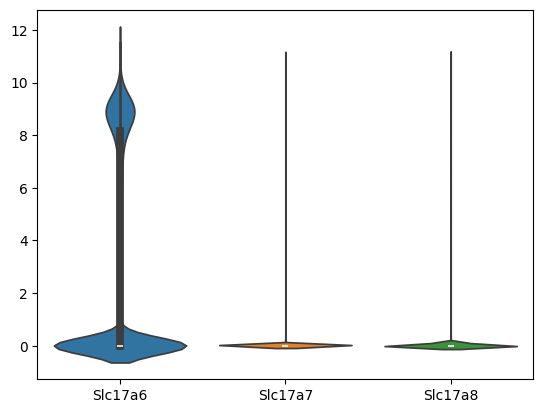

In [ ]:
# create violin plot of gene table
import seaborn as sns

sns.violinplot(data=gene_table)
plt.show()

If you want to make a plot for a specific class, subclass, supertype, or cluster within the chosen cell-by-gene matrix, continue below.

In [ ]:
# filter cells by class, subclass, supertype, or cluster
filtered_matrix_cells_with_genes = matrix_cells_with_genes[matrix_cells_with_genes['class'] == '22 MB-HB Sero'] # change filter here
filtered_matrix_cells_with_genes.head(5) # show me first 5 cells

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,Slc17a7,Slc17a6,Slc17a8
cell_label,,,,,,,,,,,,,,,,,,,,,
GAATCACAGCTGACCC-149_C01,GAATCACAGCTGACCC,149_C01,L8TX_190822_01_A11,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-482568,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#533691,#EC4067,#99FFE4,#1F2E66,#FF8F26,25,#CC5CB0,0.0,0.0,0.0
CTTCTCTCATTCTCCG-433_C01,CTTCTCTCATTCTCCG,433_C01,L8TX_201120_01_F09,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-553676,Ai14(RCL-tdT)/wt,...,#533691,#EC4067,#99FFE4,#1F2E66,#FF8F26,25,#CC5CB0,0.0,0.0,0.0
GGTGTCGAGAAGTATC-427_C05,GGTGTCGAGAAGTATC,427_C05,L8TX_201112_01_H04,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-551628,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#533691,#EC4067,#99FFE4,#1F2E66,#FF8F26,25,#CC5CB0,0.0,0.0,0.0
CGCATAATCGTGGGAA-149_C01,CGCATAATCGTGGGAA,149_C01,L8TX_190822_01_A11,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-482568,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#533691,#EC4067,#99FFE4,#1F2E66,#FF8F26,25,#CC5CB0,0.0,0.0,0.0
ACCACAACACTGCATA-194_B01,ACCACAACACTGCATA,194_B01,L8TX_191217_01_A05,WMB-10Xv3-MB,cell,NaN,10Xv3,MB,Snap25-IRES2-Cre;Ai14-499298,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#533691,#EC4067,#99FFE4,#1F2E66,#FF8F26,25,#CC5CB0,0.0,0.0,0.0


In [ ]:
# show me how many cells are in my filtered group
len(filtered_matrix_cells_with_genes)

1508

In [ ]:
# make a table with my genes of interest and my cell-by-gene matrix
filtered_gene_table = (filtered_matrix_cells_with_genes[['Slc17a6', 'Slc17a7', 'Slc17a8']]) # edit genes of interest here
filtered_gene_table.head(5) # show me first 5 cells

,Slc17a6,Slc17a7,Slc17a8
cell_label,,,
GAATCACAGCTGACCC-149_C01,0.0,0.0,0.0
CTTCTCTCATTCTCCG-433_C01,0.0,0.0,0.0
GGTGTCGAGAAGTATC-427_C05,0.0,0.0,0.0
CGCATAATCGTGGGAA-149_C01,0.0,0.0,0.0
ACCACAACACTGCATA-194_B01,0.0,0.0,0.0


In [ ]:
# save table as a .csv file. saved file will appear in 'files' tab on the left sidebar
filtered_gene_table.to_csv('filtered_sc_gene_table.csv') # edit name of .csv file here

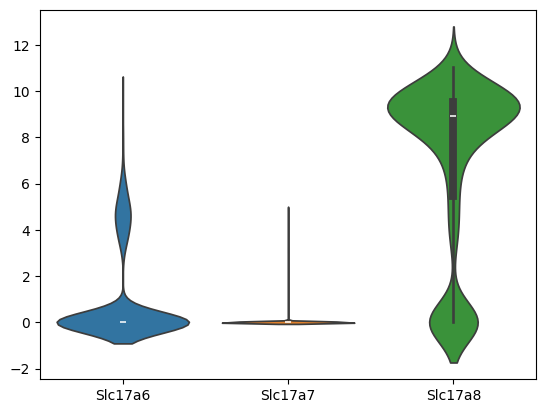

In [ ]:
# create violin plot of filtered gene table
sns.violinplot(data=filtered_gene_table)
plt.show()